# PHISHING WEBSITES CLASSIFICATION - kNN
## Dataset: UCI Phishing Websites Dataset
## 30 Features | Binary Classification (Legitimate vs Phishing)

## 1. DATA PREPARATION (Reuse from Decision Tree)

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2 Load Dataset

In [2]:
df = pd.read_csv('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/data/phishing_data.csv')
print(f"Dataset Shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}")

Dataset Shape: (11055, 31)
Features: 30


### 1.3 Feature & Target Preparation

In [3]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(f"Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

Features Shape: (11055, 30)
Target Shape: (11055,)


### 1.4 Train-Test Split (Same as Decision Tree)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")

Training Set: 8844 samples
Test Set: 2211 samples


### 1.5 Feature Scaling (CRITICAL for kNN)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")
print(f"Mean of scaled training data: {X_train_scaled.mean():.6f}")
print(f"Std of scaled training data: {X_train_scaled.std():.6f}")

Feature scaling completed
Mean of scaled training data: 0.000000
Std of scaled training data: 1.000000


## 2. FINDING OPTIMAL k VALUE - 4 marks

### 2.1 k-Value Grid Search

In [6]:
print("="*60)
print("FINDING OPTIMAL k VALUE")
print("="*60)

k_values = range(3, 31, 2)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"k={k:2d} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

FINDING OPTIMAL k VALUE
k= 3 | Train: 0.9750 | Test: 0.9484
k= 5 | Train: 0.9661 | Test: 0.9493
k= 7 | Train: 0.9583 | Test: 0.9457
k= 9 | Train: 0.9534 | Test: 0.9453
k=11 | Train: 0.9522 | Test: 0.9403
k=13 | Train: 0.9467 | Test: 0.9385
k=15 | Train: 0.9398 | Test: 0.9358
k=17 | Train: 0.9394 | Test: 0.9358
k=19 | Train: 0.9372 | Test: 0.9267
k=21 | Train: 0.9352 | Test: 0.9303
k=23 | Train: 0.9365 | Test: 0.9326
k=25 | Train: 0.9337 | Test: 0.9303
k=27 | Train: 0.9324 | Test: 0.9290
k=29 | Train: 0.9335 | Test: 0.9322


### 2.2 Find Best k

In [7]:
best_k = list(k_values)[np.argmax(test_accuracies)]
best_test_acc = max(test_accuracies)

print(f"\nOptimal k Value: {best_k}")
print(f"Best Test Accuracy: {best_test_acc:.4f}")


Optimal k Value: 5
Best Test Accuracy: 0.9493


### 2.3 k-Values Optimization Plot

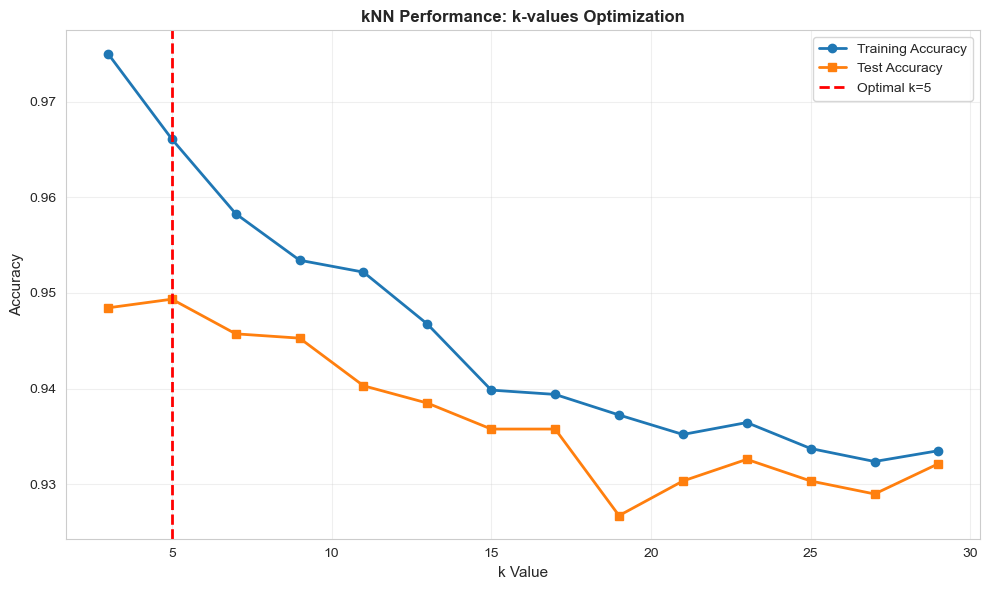

k-values optimization plot saved


In [8]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, marker='o', label='Training Accuracy', linewidth=2, markersize=6)
plt.plot(k_values, test_accuracies, marker='s', label='Test Accuracy', linewidth=2, markersize=6)
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Optimal k={best_k}')
plt.xlabel('k Value', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('kNN Performance: k-values Optimization', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/plots/knn_k_values_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("k-values optimization plot saved")

## 3. BUILD FINAL kNN MODEL - 4 marks

### 3.1 Build Final Model with Optimal k

In [9]:
print("="*60)
print(f"FINAL kNN MODEL (k={best_k})")
print("="*60)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

print(f"Model Parameters:")
print(f"  • n_neighbors (k): {best_k}")
print(f"  • algorithm: {knn_model.algorithm}")
print(f"  • metric: {knn_model.metric}")
print(f"  • p: {knn_model.p}")

FINAL kNN MODEL (k=5)
Model Parameters:
  • n_neighbors (k): 5
  • algorithm: auto
  • metric: minkowski
  • p: 2


### 3.2 Cross-Validation

In [10]:
cv_scores = cross_val_score(
    knn_model, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)

print(f"\n5-Fold Cross-Validation Results:")
print(f"Fold Scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")


5-Fold Cross-Validation Results:
Fold Scores: ['0.9384', '0.9378', '0.9367', '0.9288', '0.9434']
Mean CV Accuracy: 0.9370
Std Dev: 0.0047


## 4. EVALUATION - 4 marks

### 4.1 Predictions

In [11]:
y_train_pred = knn_model.predict(X_train_scaled)
y_test_pred = knn_model.predict(X_test_scaled)

print("Predictions generated")

Predictions generated


### 4.2 Training Set Performance

In [12]:
print("="*60)
print("TRAINING SET PERFORMANCE")
print("="*60)
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred)
train_rec = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print(f"Accuracy:  {train_acc:.4f}")
print(f"Precision: {train_prec:.4f}")
print(f"Recall:    {train_rec:.4f}")
print(f"F1-Score:  {train_f1:.4f}")

TRAINING SET PERFORMANCE
Accuracy:  0.9661
Precision: 0.9641
Recall:    0.9754
F1-Score:  0.9697


### 4.3 Test Set Performance

In [13]:
print("="*60)
print("TEST SET PERFORMANCE")
print("="*60)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

TEST SET PERFORMANCE
Accuracy:  0.9493
Precision: 0.9501
Recall:    0.9594
F1-Score:  0.9547


### 4.4 Confusion Matrix

In [14]:
cm_test = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix (Test Set):")
print(cm_test)
print(f"\nTrue Negatives:  {cm_test[0,0]}")
print(f"False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}")
print(f"True Positives:  {cm_test[1,1]}")

Confusion Matrix (Test Set):
[[ 918   62]
 [  50 1181]]

True Negatives:  918
False Positives: 62
False Negatives: 50
True Positives:  1181


### 4.5 Confusion Matrix Visualization

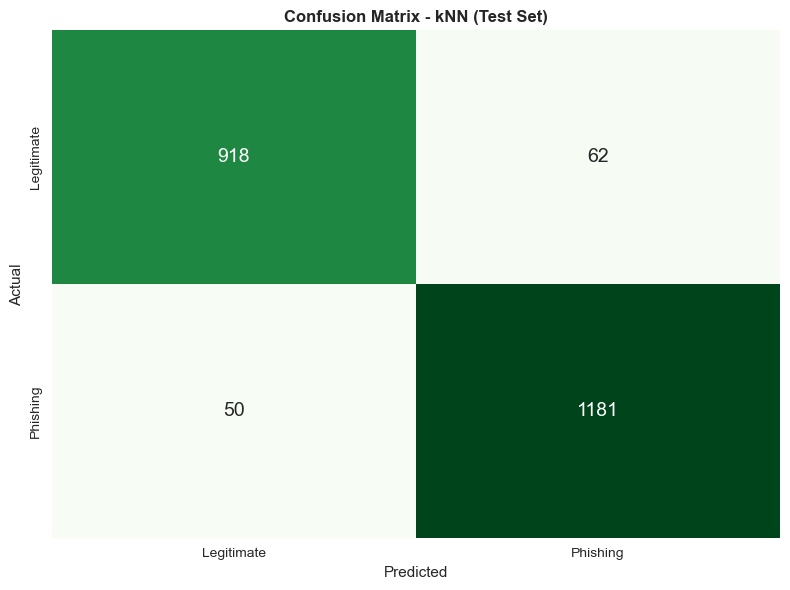

Confusion matrix plot saved


In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'],
            cbar=False, annot_kws={'size': 14})
plt.title('Confusion Matrix - kNN (Test Set)', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)
plt.tight_layout()
plt.savefig('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/plots/knn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrix plot saved")

### 4.6 Classification Report

In [16]:
print("\nDetailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred,
                          target_names=['Legitimate', 'Phishing']))


Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

  Legitimate       0.95      0.94      0.94       980
    Phishing       0.95      0.96      0.95      1231

    accuracy                           0.95      2211
   macro avg       0.95      0.95      0.95      2211
weighted avg       0.95      0.95      0.95      2211



### 4.7 Conclusion & Interpretation

In [17]:
print("="*70)
print("kNN - CONCLUSION & INTERPRETATION")
print("="*70)

print(f"""
MODEL PERFORMANCE SUMMARY:
  • Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)
  • Precision: {test_prec:.4f} - When predicting phishing, correct {test_prec*100:.1f}% of the time
  • Recall: {test_rec:.4f} - Catches {test_rec*100:.1f}% of actual phishing websites
  • F1-Score: {test_f1:.4f}
  • Cross-Validation Accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})
  • Optimal k: {best_k}

INTERPRETATION:
The kNN model with k={best_k} achieves {test_acc*100:.2f}% accuracy on the test set.
With {test_rec*100:.1f}% recall, the model effectively identifies phishing websites.
The precision of {test_prec*100:.1f}% indicates good specificity with minimal false alarms.
Cross-validation score of {cv_scores.mean():.4f} shows the model generalizes well.
Feature scaling ensures that distance-based learning is fair across all features.
""")

kNN - CONCLUSION & INTERPRETATION

MODEL PERFORMANCE SUMMARY:
  • Test Accuracy: 0.9493 (94.93%)
  • Precision: 0.9501 - When predicting phishing, correct 95.0% of the time
  • Recall: 0.9594 - Catches 95.9% of actual phishing websites
  • F1-Score: 0.9547
  • Cross-Validation Accuracy: 0.9370 (±0.0047)
  • Optimal k: 5

INTERPRETATION:
The kNN model with k=5 achieves 94.93% accuracy on the test set.
With 95.9% recall, the model effectively identifies phishing websites.
The precision of 95.0% indicates good specificity with minimal false alarms.
Cross-validation score of 0.9370 shows the model generalizes well.
Feature scaling ensures that distance-based learning is fair across all features.



### 4.8 Save Model & Scaler

In [19]:
with open('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/models/knn_model.pkl', 'wb') as f:
    pickle.dump((knn_model, scaler), f)

print("Model and scaler saved to models/knn_model.pkl")

Model and scaler saved to models/knn_model.pkl


## 5. ALGORITHM COMPARISON: Decision Tree vs kNN

### 5.1 Load Decision Tree Model

In [21]:
with open('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/models/decision_tree_model.pkl', 'rb') as f:
    dt_model = pickle.load(f)

dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_prec = precision_score(y_test, dt_pred)
dt_rec = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree model loaded")

Decision Tree model loaded


### 5.2 Comparison Table

In [22]:
print("="*70)
print("ALGORITHM COMPARISON")
print("="*70)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [f'{dt_acc:.4f}', f'{dt_prec:.4f}', f'{dt_rec:.4f}', f'{dt_f1:.4f}'],
    f'kNN (k={best_k})': [f'{test_acc:.4f}', f'{test_prec:.4f}', f'{test_rec:.4f}', f'{test_f1:.4f}']
})

print("\n" + comparison_df.to_string(index=False))

ALGORITHM COMPARISON

   Metric Decision Tree kNN (k=5)
 Accuracy        0.9403    0.9493
Precision        0.9449    0.9501
   Recall        0.9480    0.9594
 F1-Score        0.9465    0.9547


### 5.3 Comparison Visualization

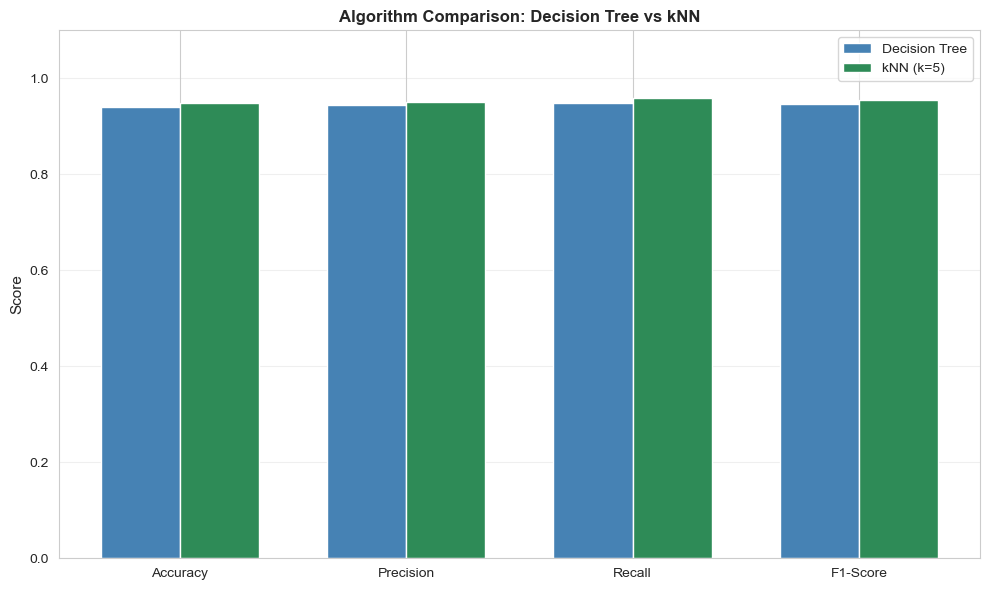

Comparison plot saved


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

dt_values = [dt_acc, dt_prec, dt_rec, dt_f1]
knn_values = [test_acc, test_prec, test_rec, test_f1]

ax.bar(x - width/2, dt_values, width, label='Decision Tree', color='steelblue')
ax.bar(x + width/2, knn_values, width, label=f'kNN (k={best_k})', color='seagreen')

ax.set_ylabel('Score', fontsize=11)
ax.set_title('Algorithm Comparison: Decision Tree vs kNN', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=10)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/Users/adarsh/Phishing Websites Classification Project/phishing-classification/plots/dt_vs_knn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Comparison plot saved")

### 5.4 Winner & Analysis

In [24]:
print("\n" + "="*70)
print("COMPARATIVE ANALYSIS")
print("="*70)

winner = "Decision Tree" if dt_acc > test_acc else "kNN"
winner_acc = max(dt_acc, test_acc)
loser_acc = min(dt_acc, test_acc)
diff = winner_acc - loser_acc

print(f"""
WINNER: {winner}
  • {winner} Accuracy: {winner_acc:.4f}
  • Accuracy Difference: {diff:.4f} ({diff*100:.2f}%)

KEY FINDINGS:
  • Decision Tree Accuracy: {dt_acc:.4f}
  • kNN (k={best_k}) Accuracy: {test_acc:.4f}
  • Decision Tree Precision: {dt_prec:.4f}
  • kNN Precision: {test_prec:.4f}
  • Decision Tree Recall: {dt_rec:.4f}
  • kNN Recall: {test_rec:.4f}

OBSERVATIONS:
  1. Both models show reasonable performance for phishing detection
  2. Feature scaling was critical for kNN distance calculations
  3. Decision Tree provides interpretability through feature importance
  4. kNN requires optimization of k parameter for best results
  5. The optimal k={best_k} balances bias-variance tradeoff
""")


COMPARATIVE ANALYSIS

WINNER: kNN
  • kNN Accuracy: 0.9493
  • Accuracy Difference: 0.0090 (0.90%)

KEY FINDINGS:
  • Decision Tree Accuracy: 0.9403
  • kNN (k=5) Accuracy: 0.9493
  • Decision Tree Precision: 0.9449
  • kNN Precision: 0.9501
  • Decision Tree Recall: 0.9480
  • kNN Recall: 0.9594

OBSERVATIONS:
  1. Both models show reasonable performance for phishing detection
  2. Feature scaling was critical for kNN distance calculations
  3. Decision Tree provides interpretability through feature importance
  4. kNN requires optimization of k parameter for best results
  5. The optimal k=5 balances bias-variance tradeoff

